In [1]:
import pandas as pd
import polars as pl

import polars as pl
import ioh

def postprocess_bbob(data: pl.DataFrame) -> pl.DataFrame:
    """Postprocess BBOB results by calculating log regret only for BBOB tasks."""
    
    # 1. Filter for BBOB task IDs to get the unique set for metadata lookup
    bbob_mask = pl.col("task_id").str.starts_with("bbob")
    unique_bbob_tasks = data.filter(bbob_mask).select("task_id").unique().to_series()

    if unique_bbob_tasks.is_empty():
        return data

    # 2. Build a lookup table for BBOB optima
    optima_records = []
    for task_id in unique_bbob_tasks:
        try:
            # Structure: "bbob/suite/fid/inst/..."
            parts = task_id.split("/")
            fid = int(parts[2])
            inst = int(parts[3])
            
            problem = ioh.get_problem(fid=fid, instance=inst)
            optima_records.append({
                "task_id": task_id,
                "f_min": problem.optimum.y
            })
        except (IndexError, ValueError) as e:
            print(f"Skipping malformed BBOB task_id '{task_id}': {e}")
            continue
    
    optima_df = pl.DataFrame(optima_records)

    # 3. Join metadata and perform vectorized calculations
    # We use a left join so non-BBOB rows are preserved with nulls in new columns
    return (
        data.join(optima_df, on="task_id", how="left")
        .with_columns([
            # Calculate regret only where f_min exists (i.e., BBOB tasks)
            (pl.col("trial_value__cost_inc") - pl.col("f_min")).alias("regret")
        ])
        .with_columns([
            # Calculate log regret. Polars .log() handles nulls automatically.
            # We use a small epsilon to avoid log(0) issues.
            (pl.col("regret") + 1e-12).log().alias("log_regret")
        ])
    )



fn = "../runs_static/logs.parquet"

df = pl.read_parquet(fn)
df = df.remove(pl.col("optimizer_id").str.starts_with("PPO"))
df = postprocess_bbob(df)
df = df.with_columns(
    benchmark_id = pl.when(pl.col("task_id").str.starts_with("bbob/2"))
    .then(pl.lit("BBOB-2d"))
    .when(pl.col("task_id").str.starts_with("bbob/8"))
    .then(pl.lit("BBOB-8d"))
    .when(pl.col("task_id").str.starts_with("bbob/16"))
    .then(pl.lit("BBOB-16d"))
    .otherwise(pl.col("benchmark_id"))
)

print(df["benchmark_id"].unique())

shape: (5,)
Series: 'benchmark_id' [str]
[
	"BBOB-2d"
	"BBOB-16d"
	"BNNBO"
	"YAHPO"
	"BBOB-8d"
]


In [2]:
import pandas as pd
import polars as pl
from typing import Union

def get_virtual_best_solver(
    df: pd.DataFrame | pl.DataFrame, 
    vbs_policies: list,
    key_performance: str = "trial_value__cost_inc"
) -> pd.DataFrame | pl.DataFrame:
    """
    Constructs the Virtual Best Solver (VBS) by selecting the best performing 
    policy per run from a subset of available policies.

    Parameters
    ----------
    df : Union[pd.DataFrame, pl.DataFrame]
        The input trace data.
    vbs_policies : list
        List of optimizer_id strings to consider for the VBS.
    key_performance : str
        The metric to minimize to determine 'best'.

    Returns
    -------
    The VBS dataframe with updated 'optimizer_id' and 'optimizer_id_source'.
    """
    group_cols = ["task_id", "seed"] # A 'run' within the context of a VBS over optimizers

    # --- Polars Implementation ---
    if isinstance(df, pl.DataFrame):
        vbs_df = (
            df.filter(pl.col("optimizer_id").is_in(vbs_policies))
            .sort(key_performance)
            .group_by(group_cols)
            .first()
            .with_columns([
                pl.col("optimizer_id").alias("optimizer_id_source"),
                pl.lit("VBS").alias("optimizer_id")
            ])
        )
        return vbs_df

    # --- Pandas Implementation ---
    if isinstance(df, pd.DataFrame):
        # Filter to allowed policies
        mask = df["optimizer_id"].isin(vbs_policies)
        vbs_df = df[mask].copy()

        # Sort and take the best per run
        vbs_df = (
            vbs_df.sort_values(key_performance)
            .groupby(group_cols, as_index=False)
            .first()
        )

        # Rename and assign new ID
        vbs_df["optimizer_id_source"] = vbs_df["optimizer_id"]
        vbs_df["optimizer_id"] = "VBS"

        return vbs_df

    raise ValueError(f"Cannot process type {type(df)}")

# Usage
vbs_policies = [o for o in df["optimizer_id"].unique() if o.startswith("Static")]
df_vbs = get_virtual_best_solver(df, vbs_policies)


# Returns a new DataFrame with the added column
df = df.with_columns(
    pl.col("optimizer_id").alias("optimizer_id_source")
)
df_vbs = df_vbs.select(df.columns)
df = pl.concat([df, df_vbs])

Benchmark: ('BNNBO',)


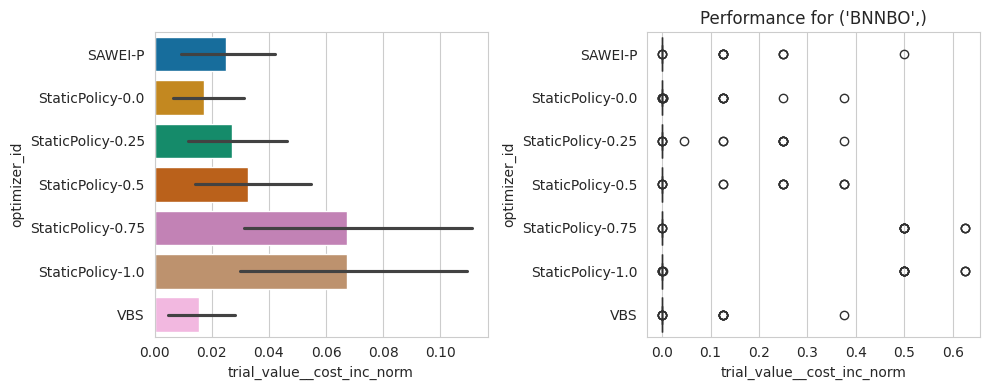

Benchmark: ('BBOB-2d',)


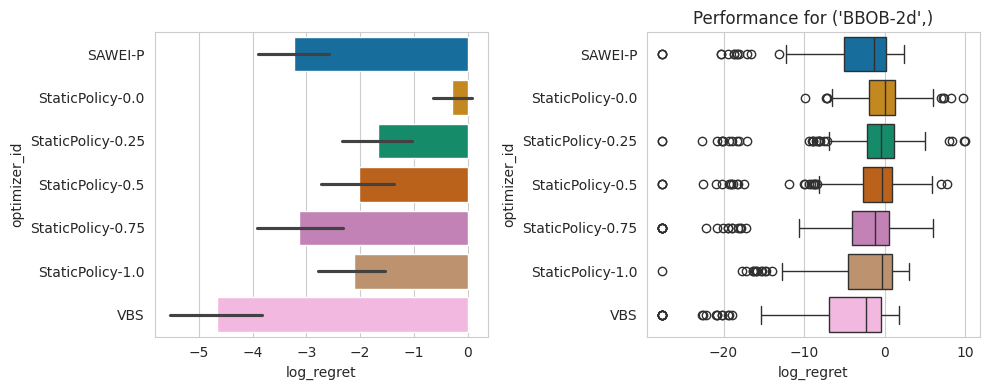

Benchmark: ('YAHPO',)


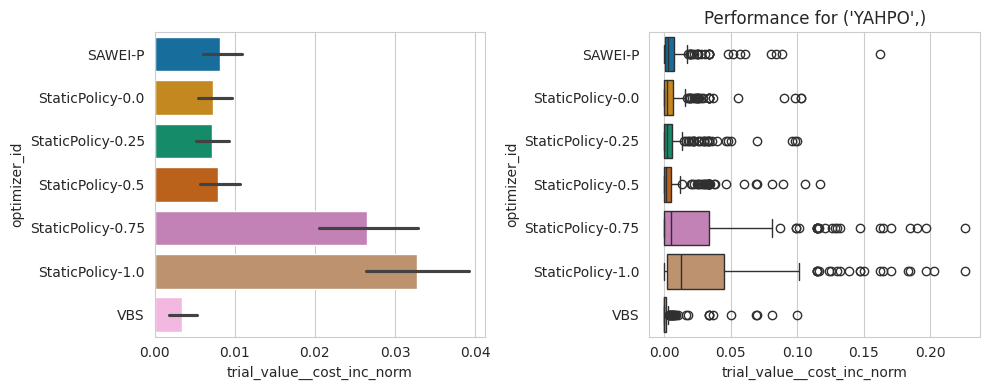

Benchmark: ('BBOB-8d',)


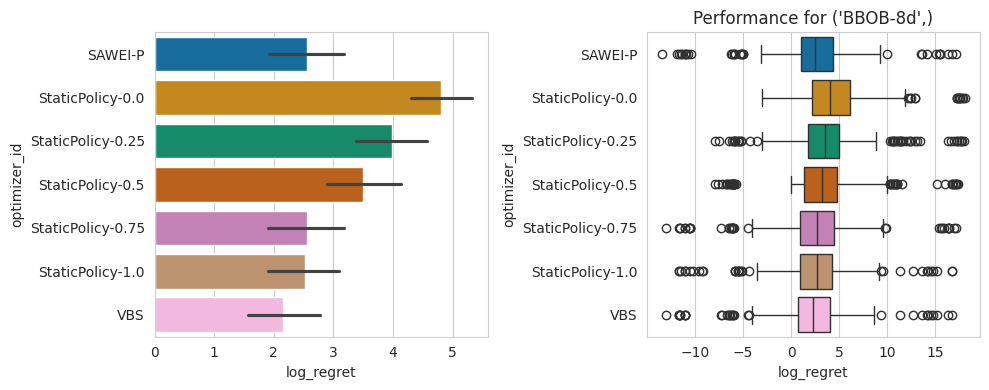

Benchmark: ('BBOB-16d',)


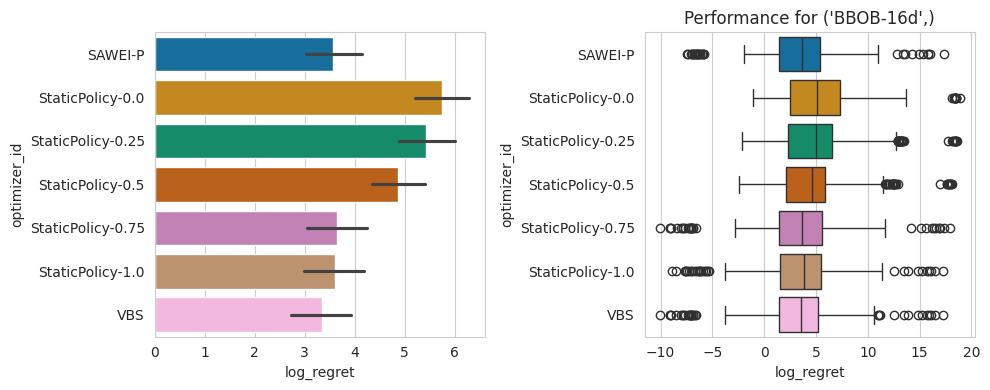

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from carps.analysis.utils import setup_seaborn, filter_only_final_performance

setup_seaborn()

dfp = df[["benchmark_id", "optimizer_id", "task_id", "seed", "trial_value__cost_inc", "trial_value__cost_inc_norm", "n_trials_norm", "log_regret"]]
dfp = filter_only_final_performance(dfp)

for benchmark_id, gdf in dfp.group_by("benchmark_id"):
    print(f"Benchmark: {benchmark_id}")

    key_performance = "log_regret" if benchmark_id[0].startswith("BBOB") else "trial_value__cost_inc_norm"

    # 1. Sort the Polars DataFrame
    # Note: sort() in Polars is not in-place
    gdf_sorted = gdf.sort("optimizer_id")

    # 2. Convert to Pandas for Seaborn 
    # (Seaborn often handles categorical ordering better from explicit lists)
    plot_data = gdf_sorted.to_pandas()

    # 3. Plot
    fig = plt.figure(figsize=(10, 4))
    axes = fig.subplots(nrows=1, ncols=2)
    sns.barplot(
        data=plot_data, 
        x=key_performance, 
        y="optimizer_id", 
        hue="optimizer_id",
        # This ensures the order of the Y-axis matches the sorted DataFrame
        order=plot_data["optimizer_id"].unique(),
        ax=axes[0]
    )
    sns.boxplot(
        data=plot_data, 
        x=key_performance, 
        y="optimizer_id", 
        hue="optimizer_id",
        # This ensures the order of the Y-axis matches the sorted DataFrame
        order=plot_data["optimizer_id"].unique(),
        ax=axes[1]
    )

    plt.title(f"Performance for {benchmark_id}")
    plt.tight_layout()
    plt.show()


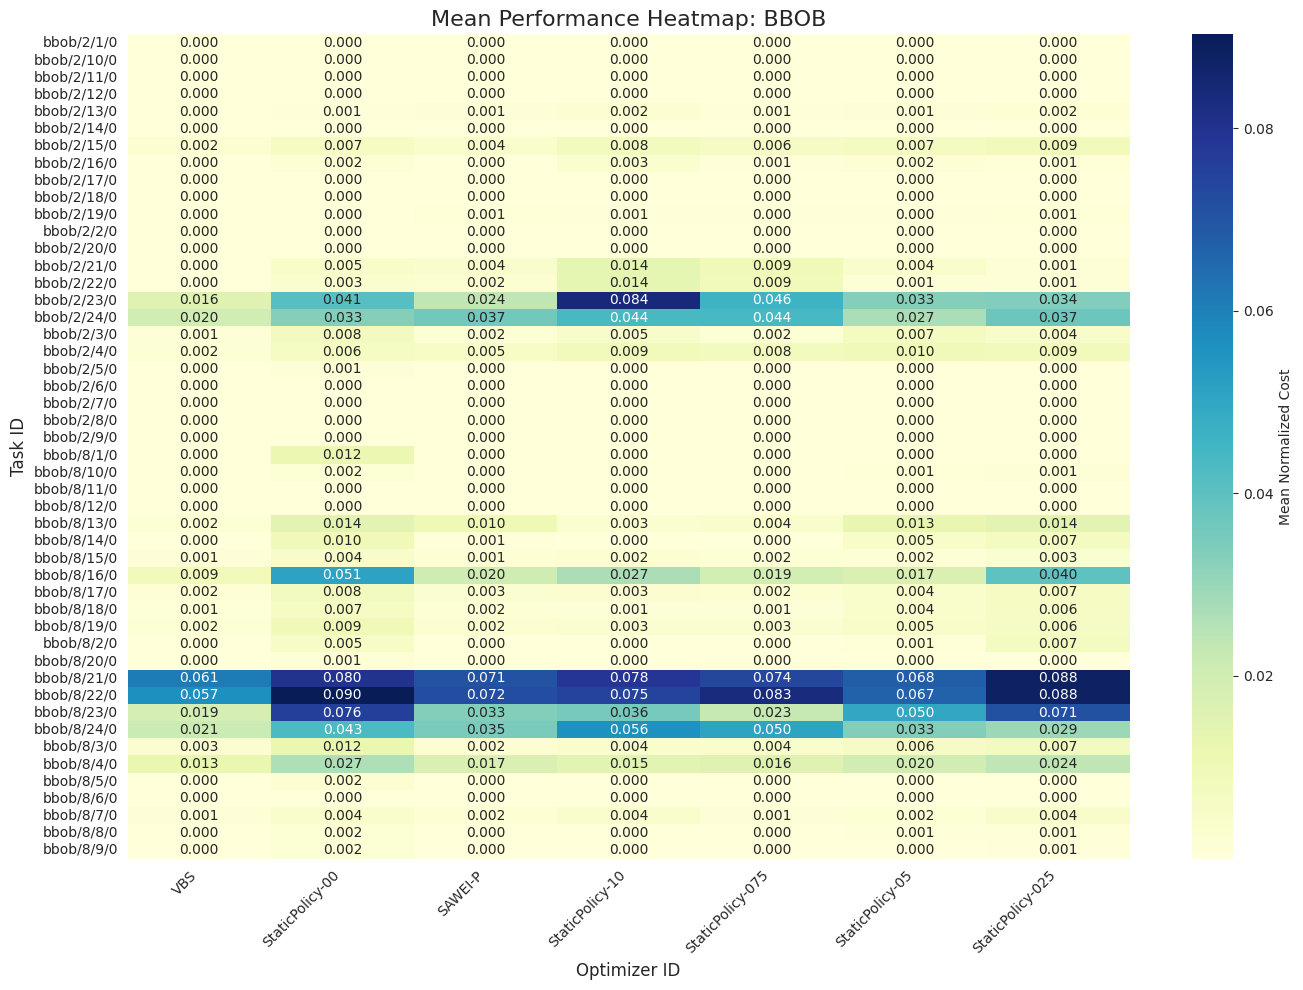

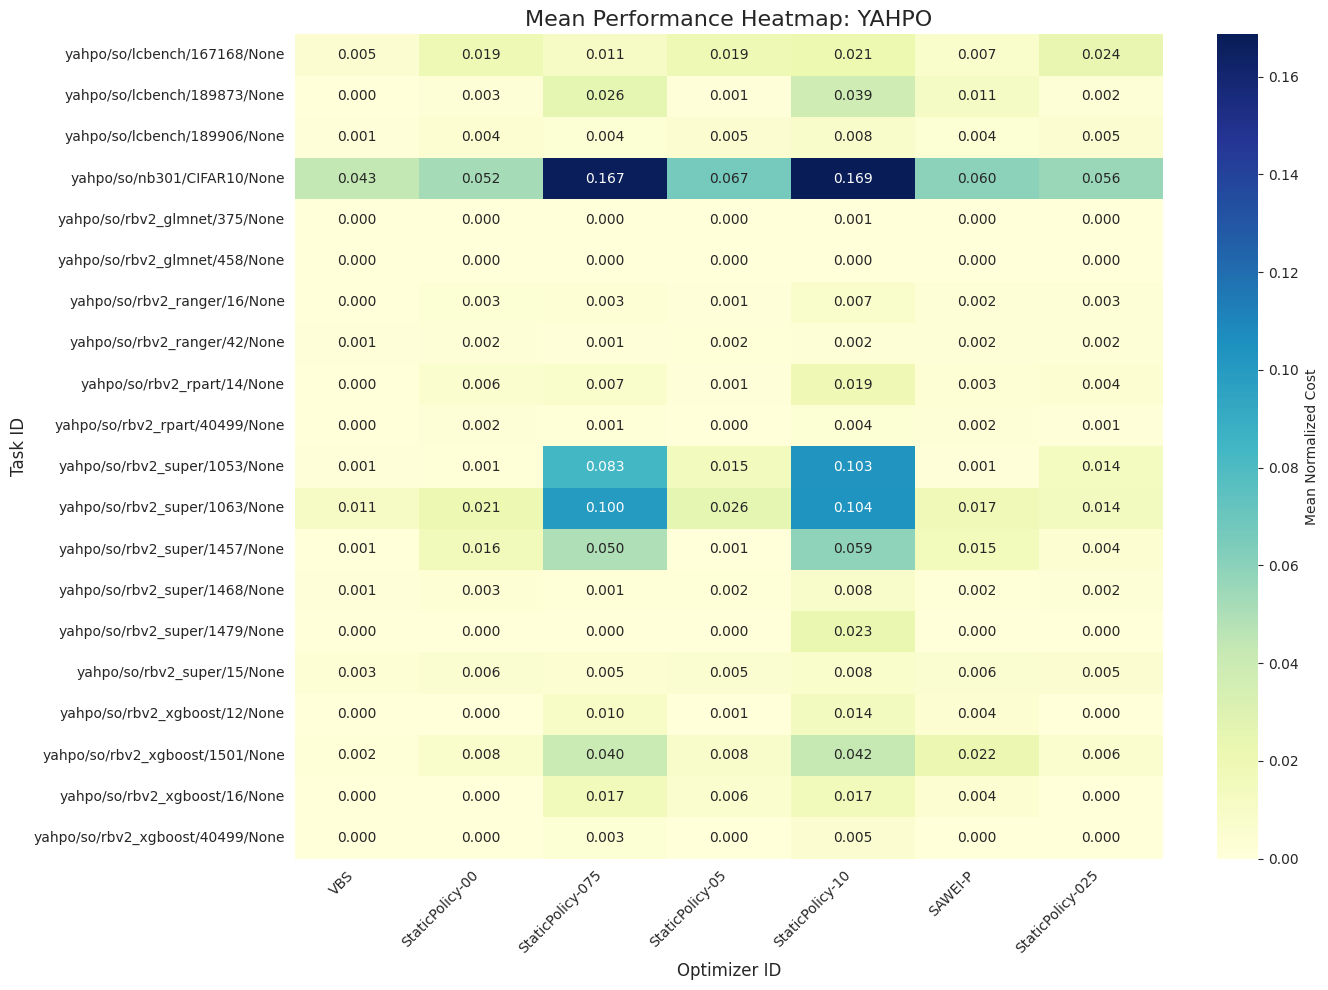

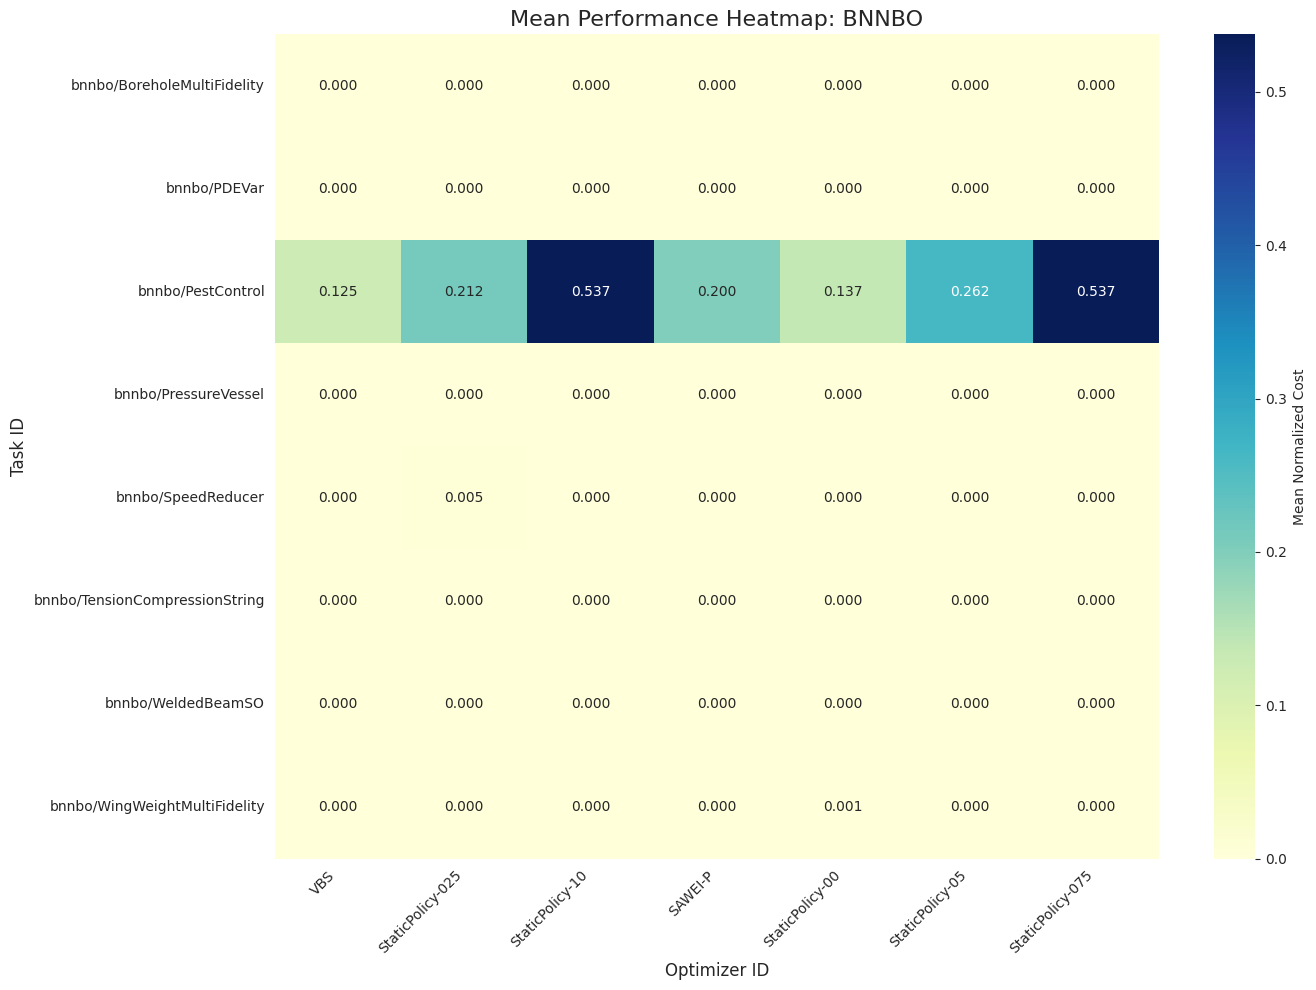

In [17]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dfp is your Polars DataFrame
for (benchmark_id,), gdf in dfp.group_by(["benchmark_id"]):
    gdf = gdf.sort("optimizer_id")
    
    # 1. Aggregate and Pivot
    # We calculate the mean cost and move optimizers to the columns
    heatmap_data = (
        gdf.group_by(["optimizer_id", "task_id"])
        .agg(pl.col("trial_value__cost_inc_norm").mean())
        .pivot(
            index="task_id", 
            on="optimizer_id", 
            values="trial_value__cost_inc_norm"
        )
        .sort("task_id") # Ensure Y-axis is ordered
        .to_pandas()     # Convert to Pandas for Seaborn heatmap compatibility
        .set_index("task_id")
    )

    # 2. Plotting
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        heatmap_data, 
        annot=True,      # Shows the mean values in the cells
        fmt=".3f",       # Format to 3 decimal places
        cmap="YlGnBu",   # Color map (Yellow-Green-Blue)
        cbar_kws={'label': 'Mean Normalized Cost'}
    )
    
    plt.title(f"Mean Performance Heatmap: {benchmark_id}", fontsize=16)
    plt.xlabel("Optimizer ID", fontsize=12)
    plt.ylabel("Task ID", fontsize=12)
    
    # Rotate x-labels if they are long
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

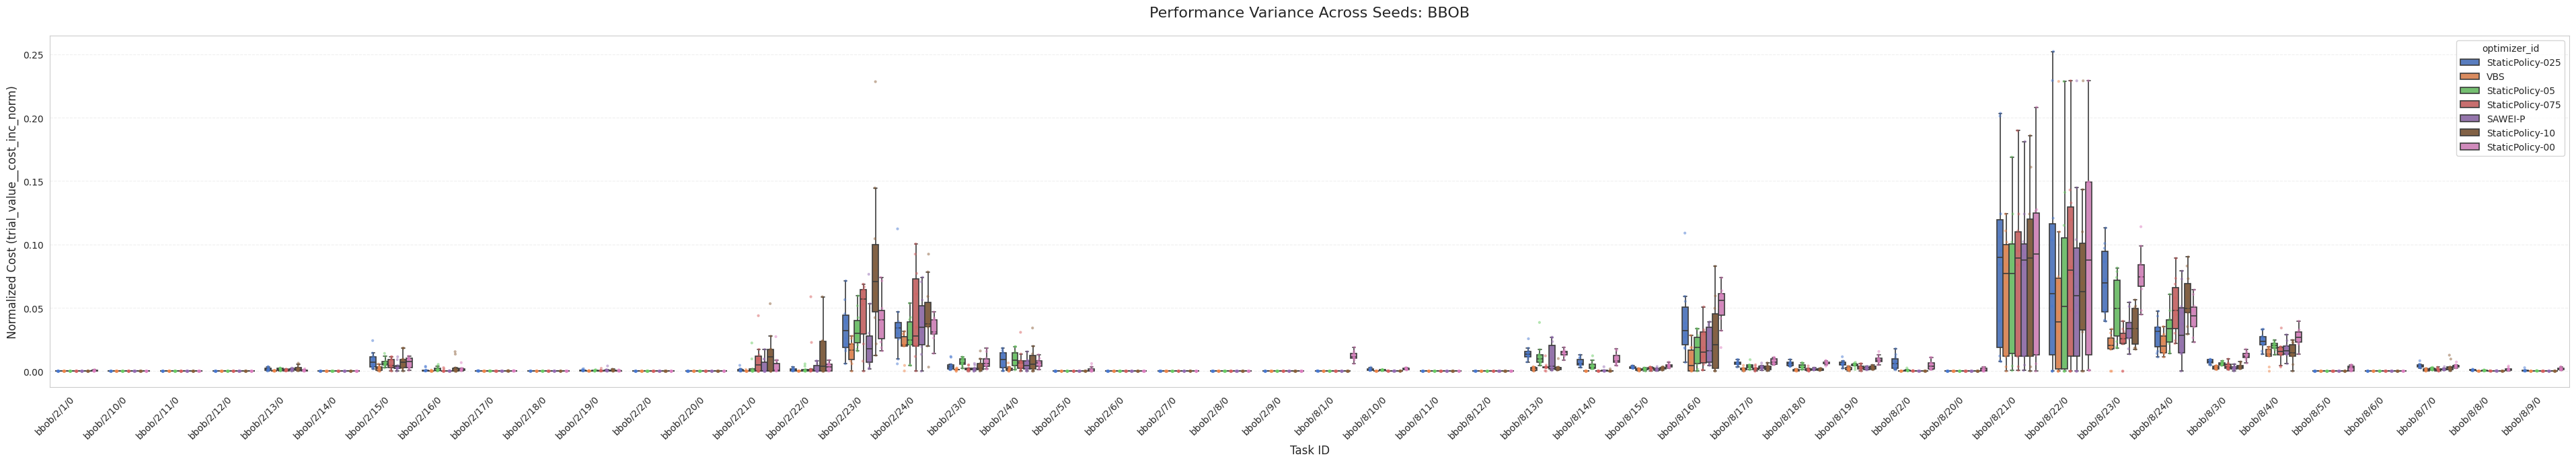

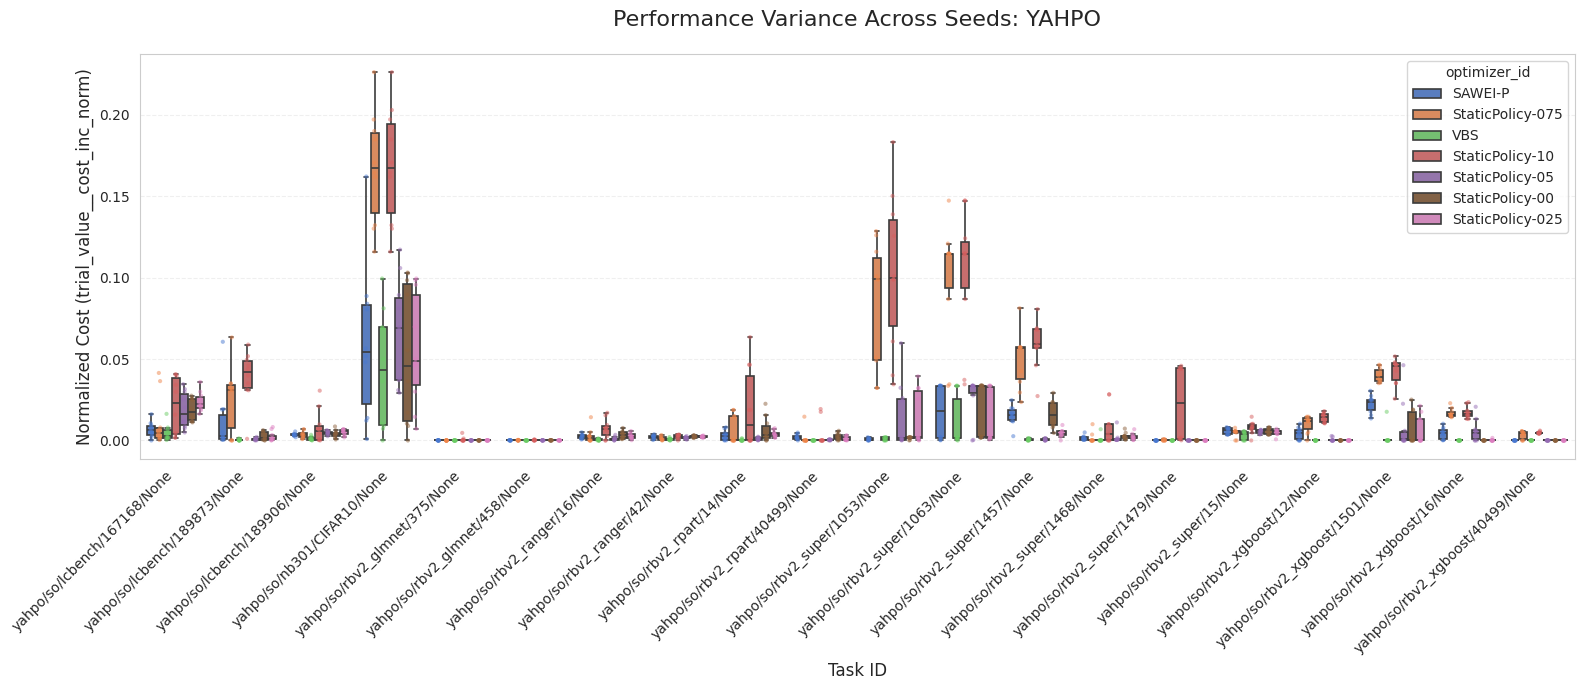

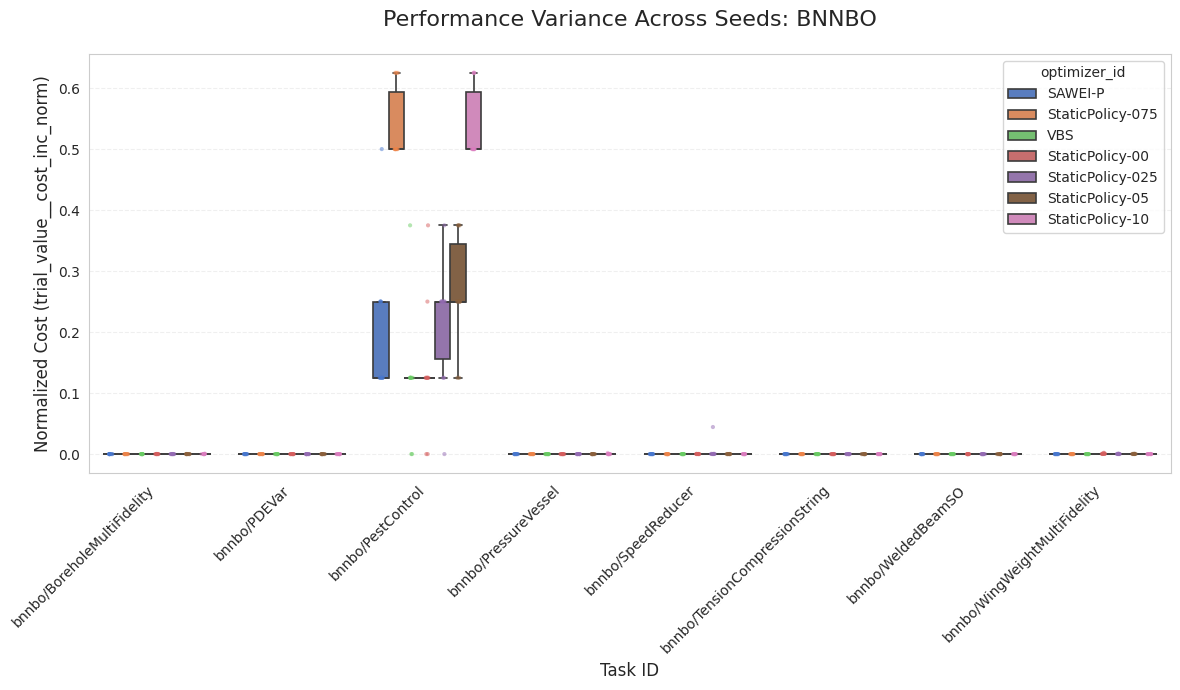

In [19]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dfp is your Polars DataFrame
for (benchmark_id,), gdf in dfp.group_by(["benchmark_id"]):
    
    # 1. Prepare data: Sort by task_id and convert to pandas for Seaborn
    plot_df = gdf.sort("task_id").to_pandas()
    
    # Calculate figure width based on the number of tasks to avoid overcrowding
    num_tasks = plot_df["task_id"].nunique()
    plt.figure(figsize=(max(12, num_tasks * 0.8), 7))
    
    # 2. Draw Boxplot (Summary of seed distributions)
    # We set fliersize=0 because the stripplot will visualize all points including outliers
    sns.boxplot(
        data=plot_df,
        x="task_id",
        y="trial_value__cost_inc_norm",
        hue="optimizer_id",
        fliersize=0,
        linewidth=1.2,
        palette="muted"
    )
    
    # 3. Draw Stripplot (Individual seed points)
    # dodge=True is essential to align the dots with the grouped boxes
    sns.stripplot(
        data=plot_df,
        x="task_id",
        y="trial_value__cost_inc_norm",
        hue="optimizer_id",
        dodge=True,
        jitter=True,
        alpha=0.5,
        size=3,
        palette="muted",
        legend=False  # Prevents duplicate legend entries
    )
    
    # 4. Styling
    plt.title(f"Performance Variance Across Seeds: {benchmark_id}", fontsize=16, pad=20)
    plt.ylabel("Normalized Cost (trial_value__cost_inc_norm)", fontsize=12)
    plt.xlabel("Task ID", fontsize=12)
    
    # Rotate labels to ensure they are readable
    plt.xticks(rotation=45, ha='right')
    
    # Add a horizontal grid for easier comparison of values
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

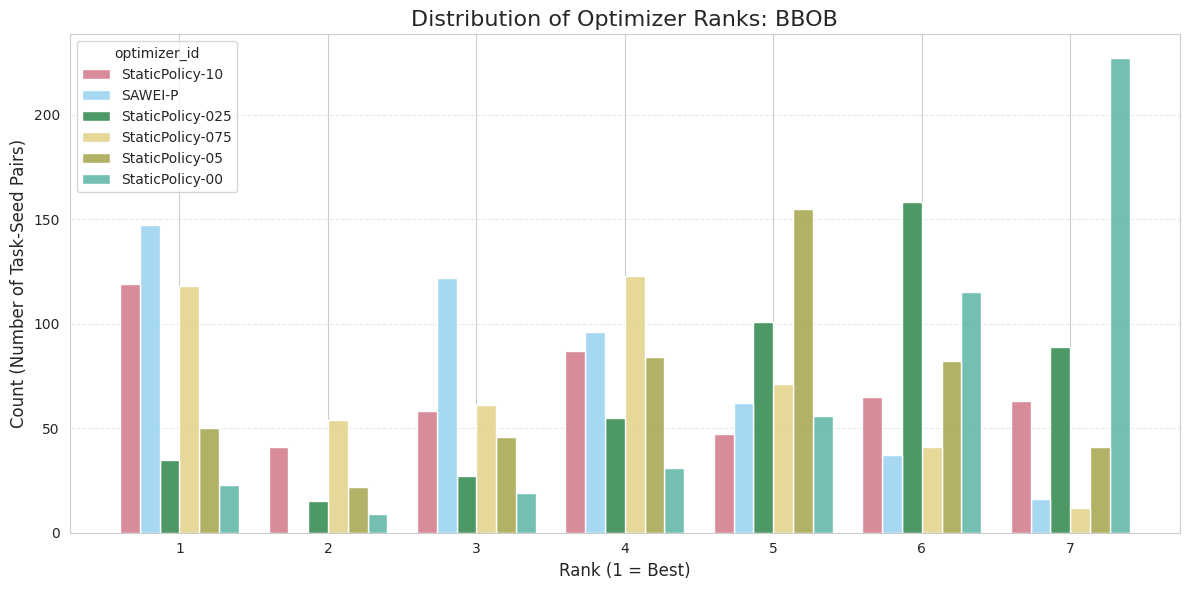

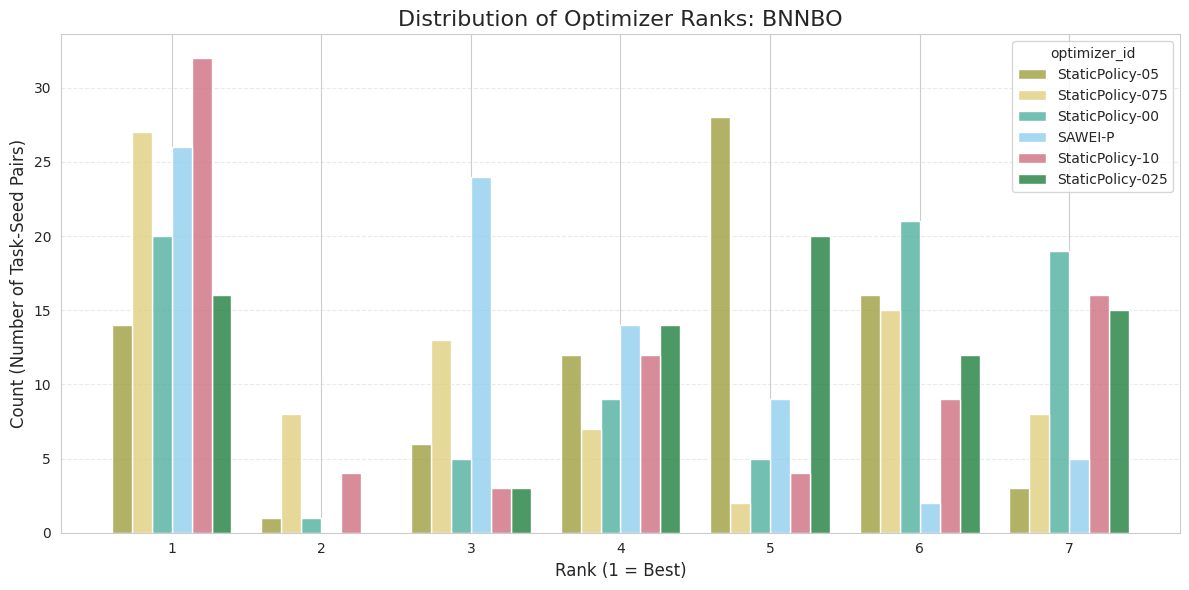

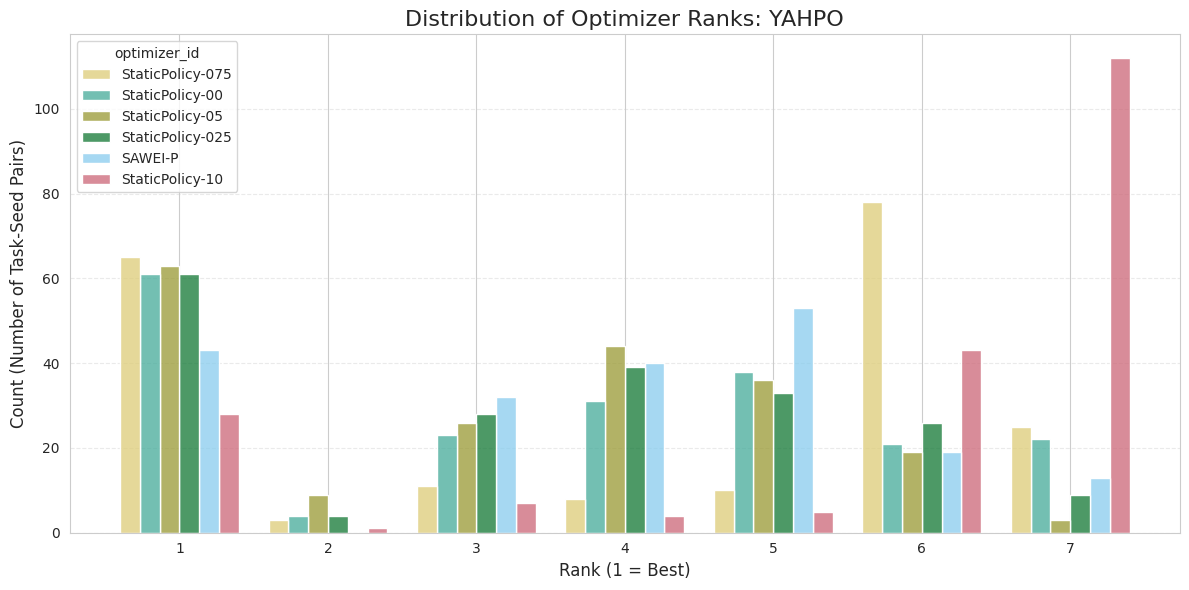

In [22]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from carps.analysis.utils import get_color_palette



# 1. Calculate ranks
# For each (benchmark, task, seed), we rank optimizers based on their performance.
# Lower cost_inc_norm = better rank (1st, 2nd, etc.)
df_ranked = dfp.with_columns(
    rank = pl.col("trial_value__cost_inc_norm")
    .rank(method="min") 
    .over(["benchmark_id", "task_id", "seed"])
)
df_ranked = df_ranked.remove(pl.col("optimizer_id") == "VBS")

palette = get_color_palette(df=df_ranked)

# 2. Generate plots per benchmark
for (benchmark_id,), gdf in df_ranked.group_by(["benchmark_id"]):
    
    # Convert to pandas for plotting
    plot_df = gdf.to_pandas()
    
    plt.figure(figsize=(12, 6))
    
    # Using histplot with discrete=True and multiple="dodge" 
    # provides a clear side-by-side comparison of ranks
    sns.histplot(
        data=plot_df,
        x="rank",
        hue="optimizer_id",
        multiple="dodge",
        discrete=True,
        shrink=0.8,
        palette=palette
    )
    
    # Formatting
    plt.title(f"Distribution of Optimizer Ranks: {benchmark_id}", fontsize=16)
    plt.xlabel("Rank (1 = Best)", fontsize=12)
    plt.ylabel("Count (Number of Task-Seed Pairs)", fontsize=12)
    
    # Ensure the X-axis shows integer ranks clearly
    max_rank = int(plot_df["rank"].max())
    plt.xticks(range(1, max_rank + 1))
    
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

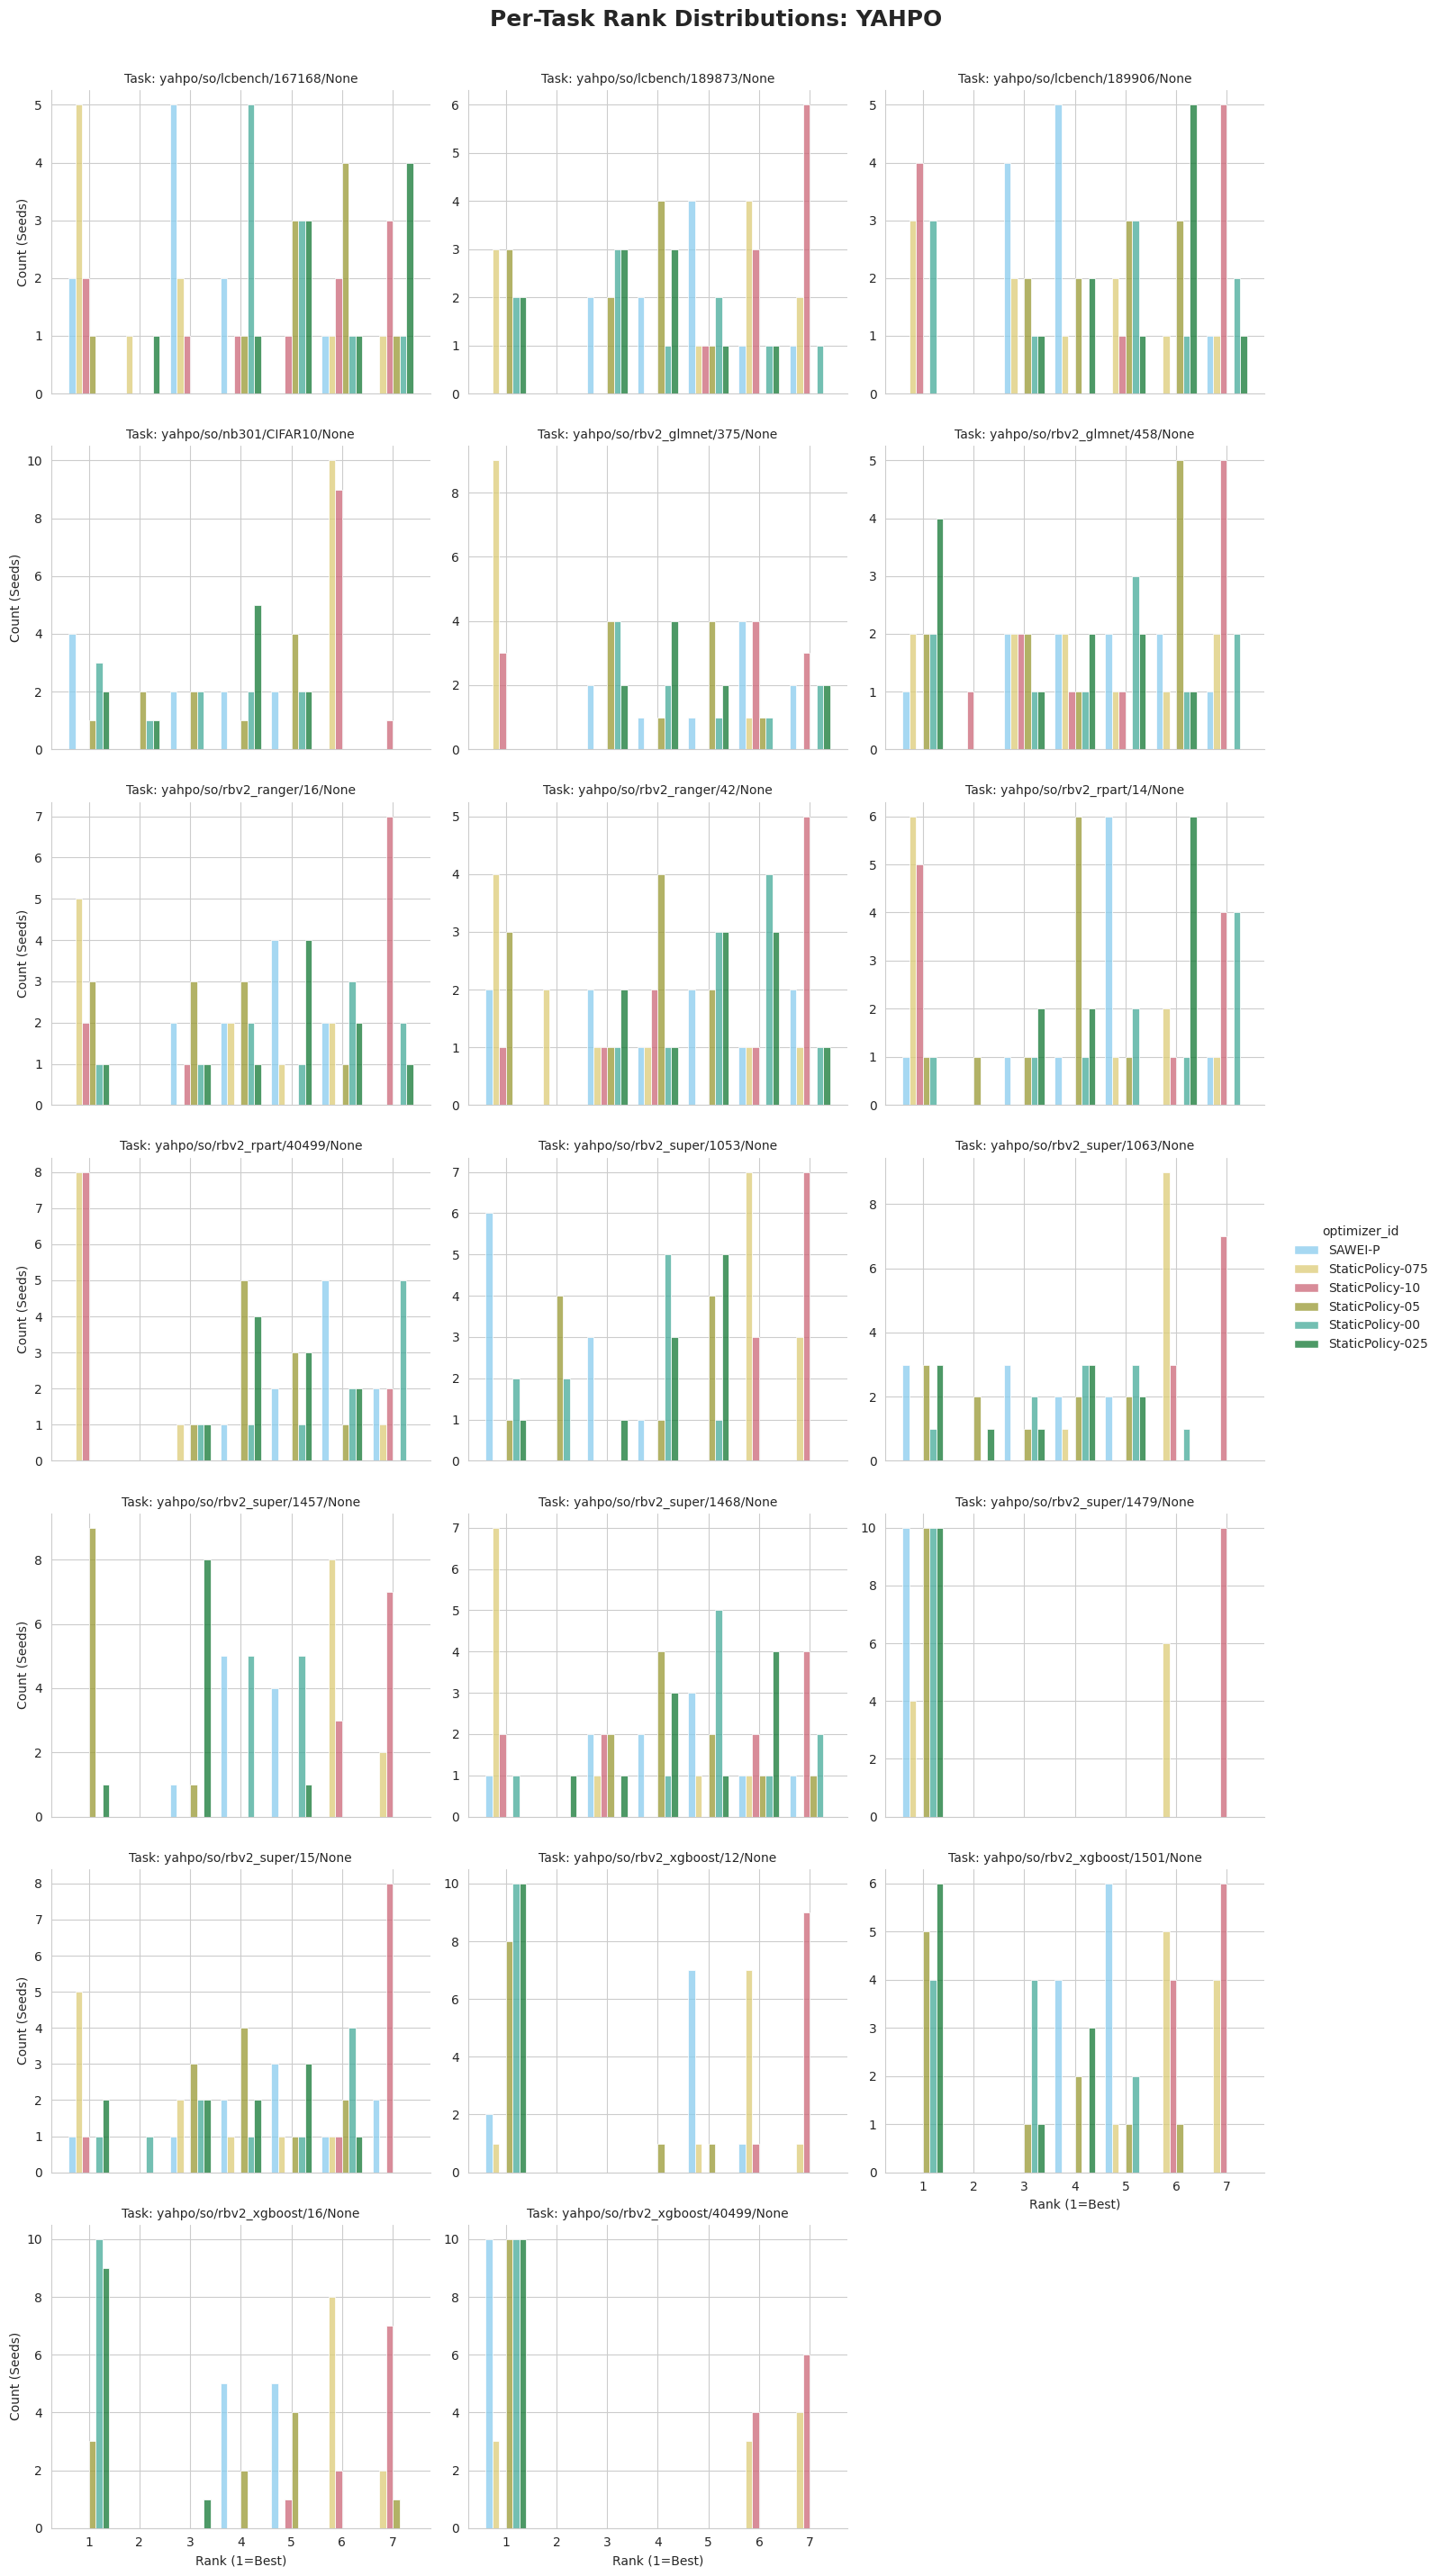

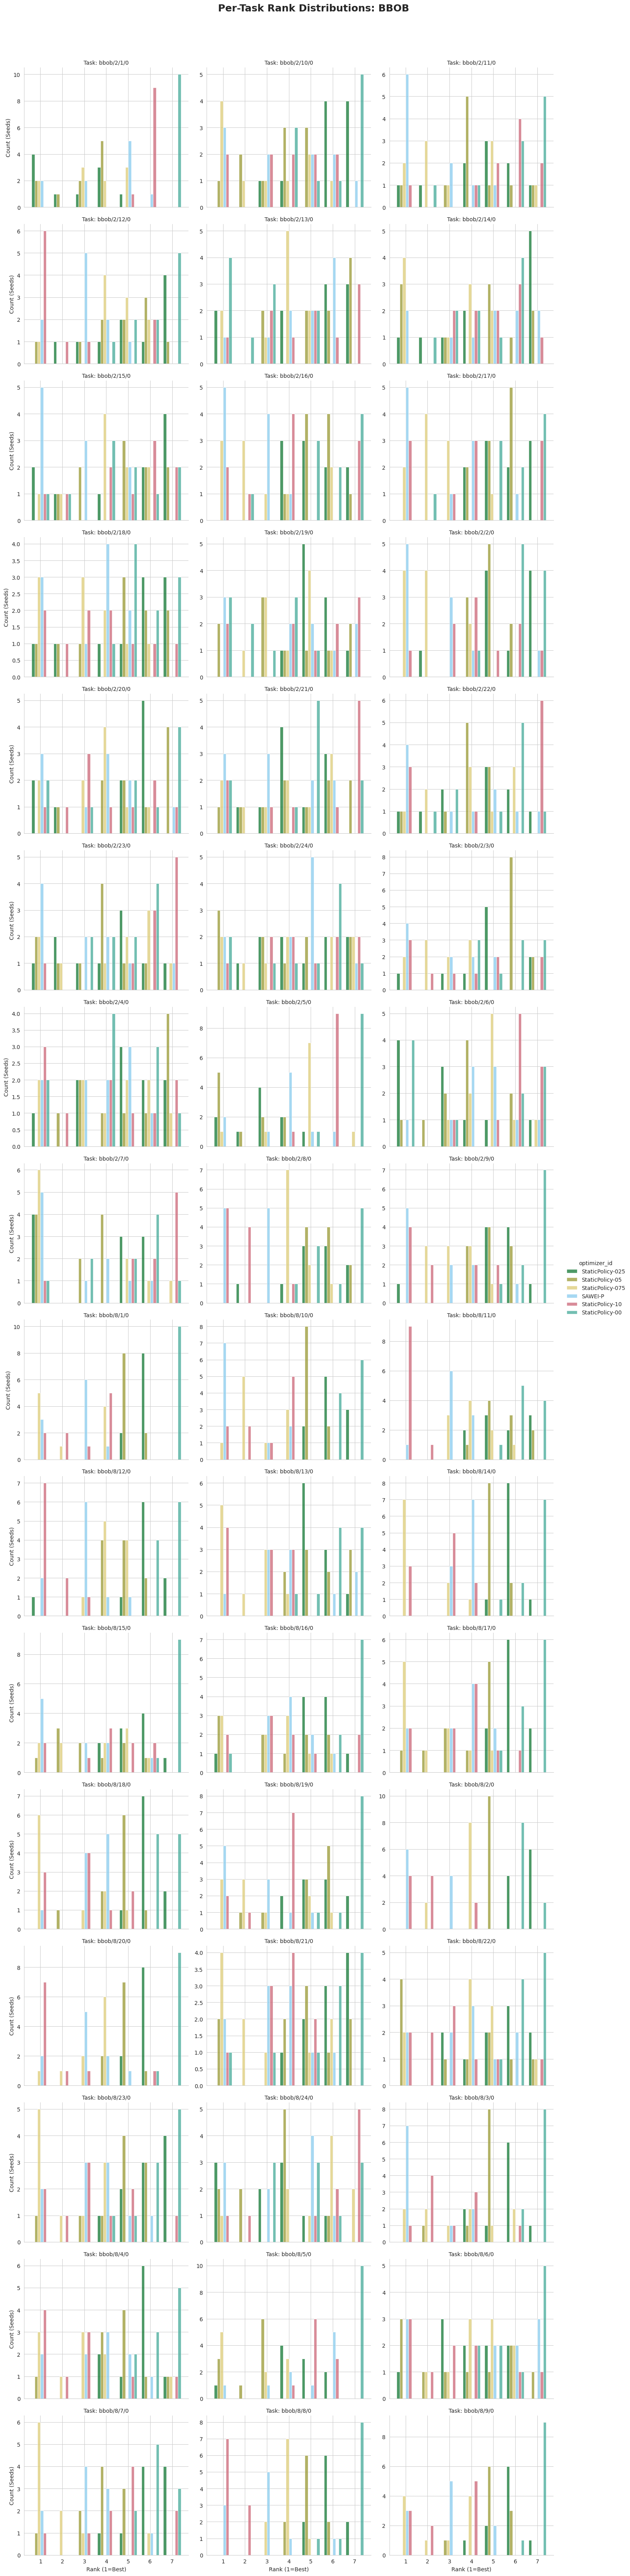

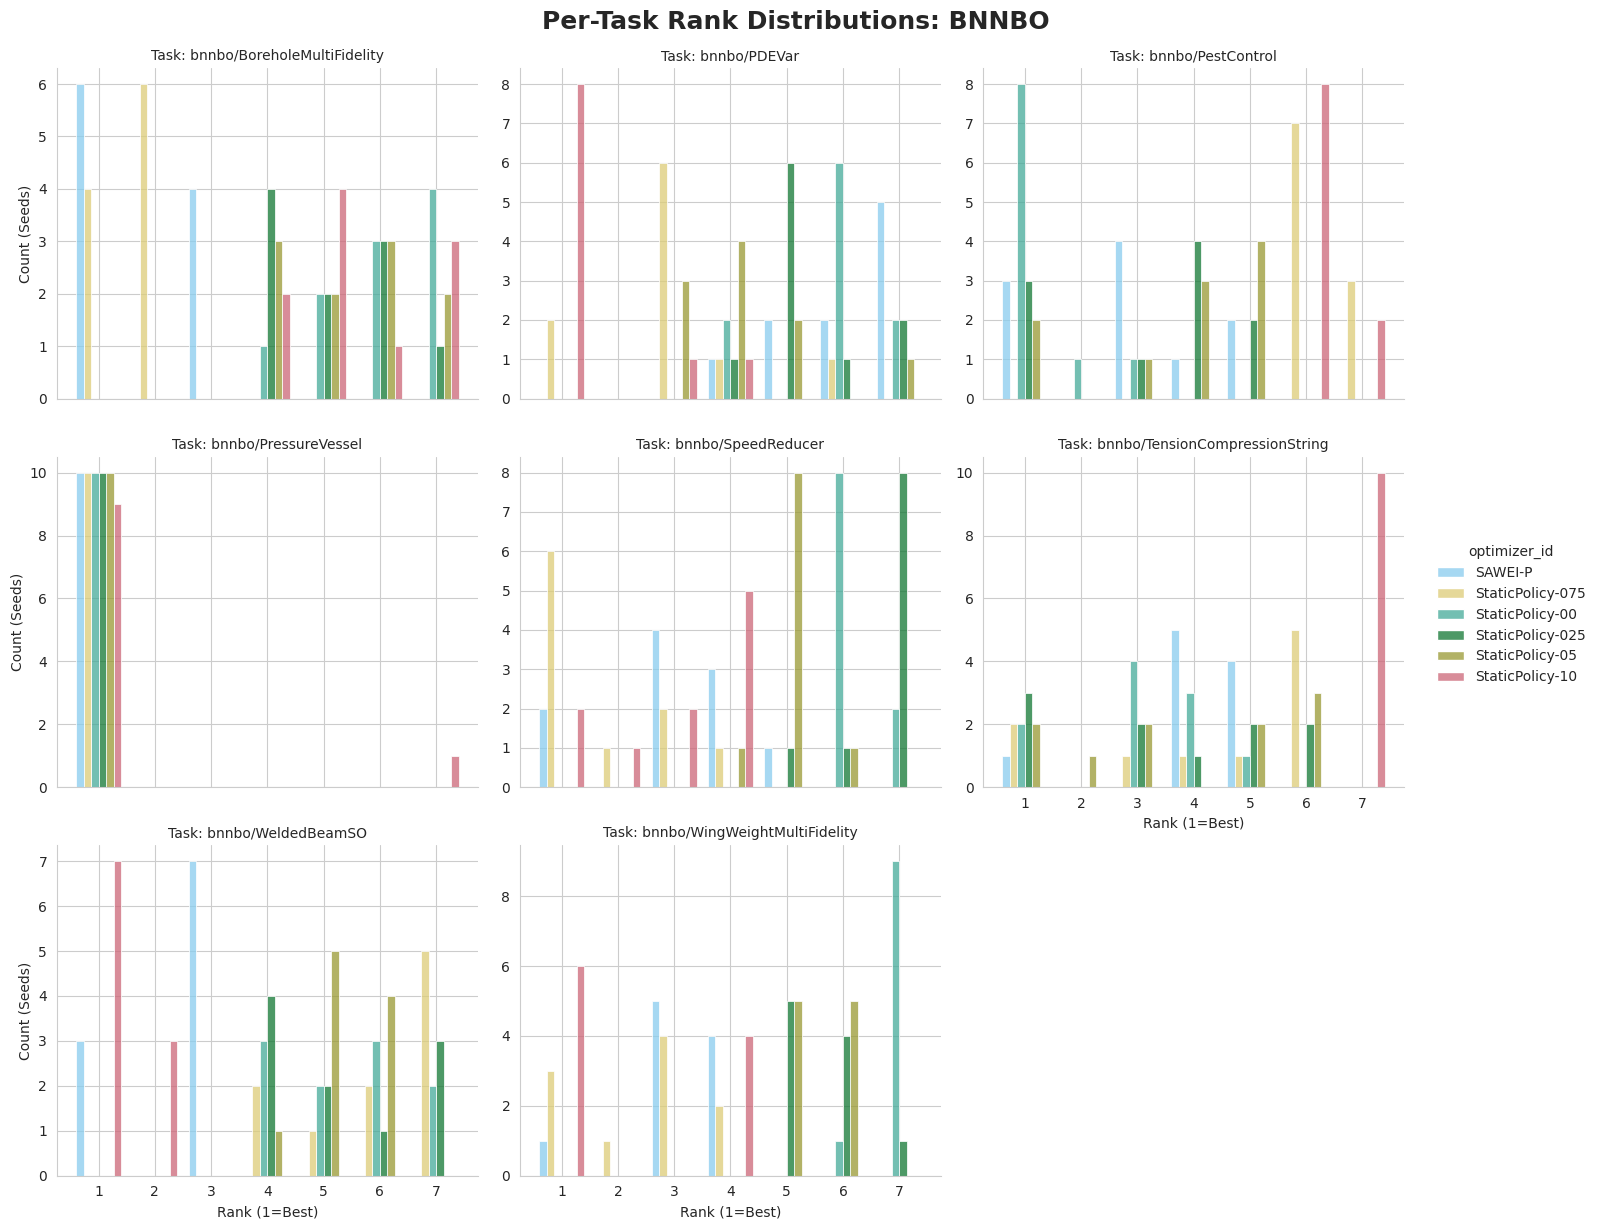

In [25]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the rank of each optimizer per run (task_id + seed)
# We use the window function .over() to ensure ranking happens within each specific run
df_ranked = dfp.with_columns(
    rank = pl.col("trial_value__cost_inc_norm")
    .rank(method="min") 
    .over(["benchmark_id", "task_id", "seed"])
)
df_ranked = df_ranked.remove(pl.col("optimizer_id") == "VBS")

palette = get_color_palette(df=df_ranked)

# 2. Iterate through each benchmark to create a separate grid
for (benchmark_id,), gdf in df_ranked.group_by(["benchmark_id"]):
    gdf = gdf.sort("task_id")
    
    # Convert the benchmark subset to Pandas for Seaborn FacetGrid
    plot_df = gdf.to_pandas()
    
    # Use displot to create a grid of histograms
    g = sns.displot(
        data=plot_df,
        x="rank",
        hue="optimizer_id",
        col="task_id",      # Create a subplot per task
        col_wrap=3,         # Wrap the grid at 3 columns for readability
        kind="hist",
        discrete=True,
        multiple="dodge",
        shrink=0.8,
        height=4,           # Height of each subplot
        aspect=1.2,         # Width-to-height ratio of each subplot
        facet_kws={'sharey': False}, # Let each task scale its own Y-axis
        palette=palette
    )
    
    # 3. Customizing the grid appearance
    g.set_titles(template="Task: {col_name}")
    g.set_axis_labels("Rank (1=Best)", "Count (Seeds)")
    
    # Adjust the title to not overlap with the plots
    g.figure.suptitle(f"Per-Task Rank Distributions: {benchmark_id}", y=1.02, fontsize=18, fontweight='bold')
    
    # Ensure the x-ticks show integer ranks
    max_rank = int(plot_df["rank"].max())
    for ax in g.axes.flat:
        ax.set_xticks(range(1, max_rank + 1))
    
    plt.show()